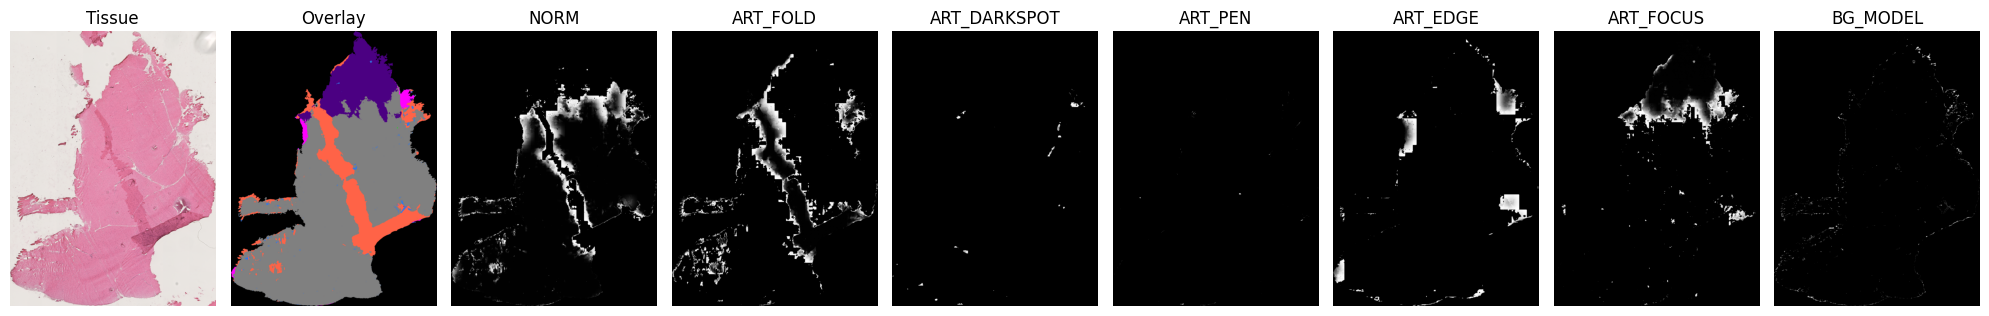

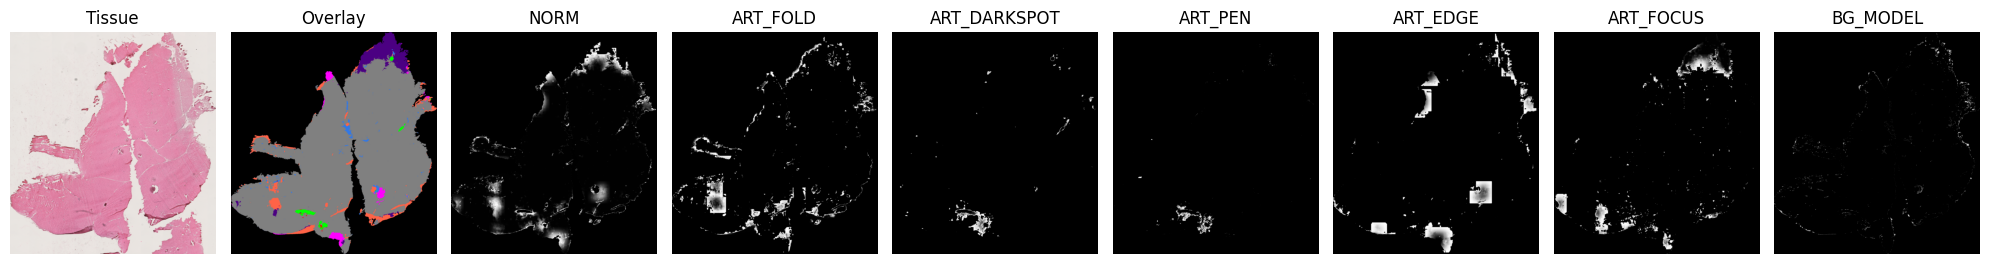

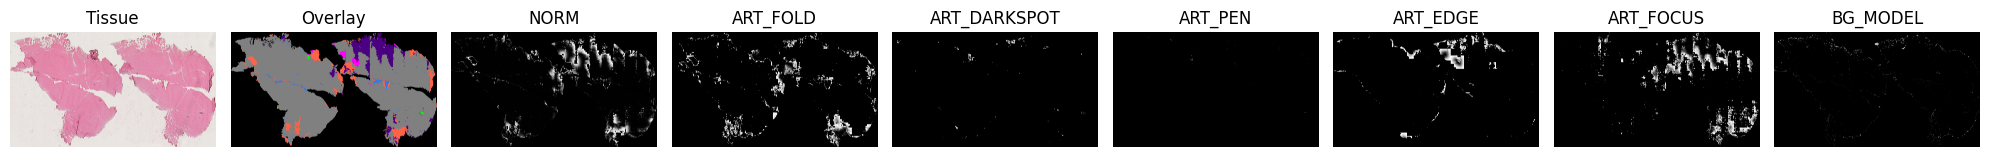

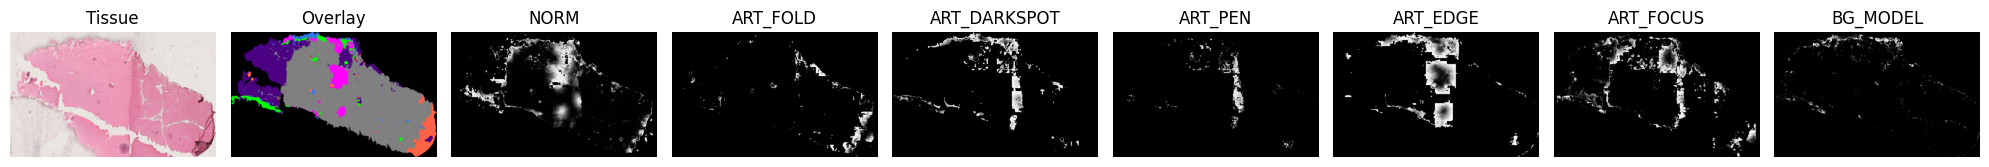

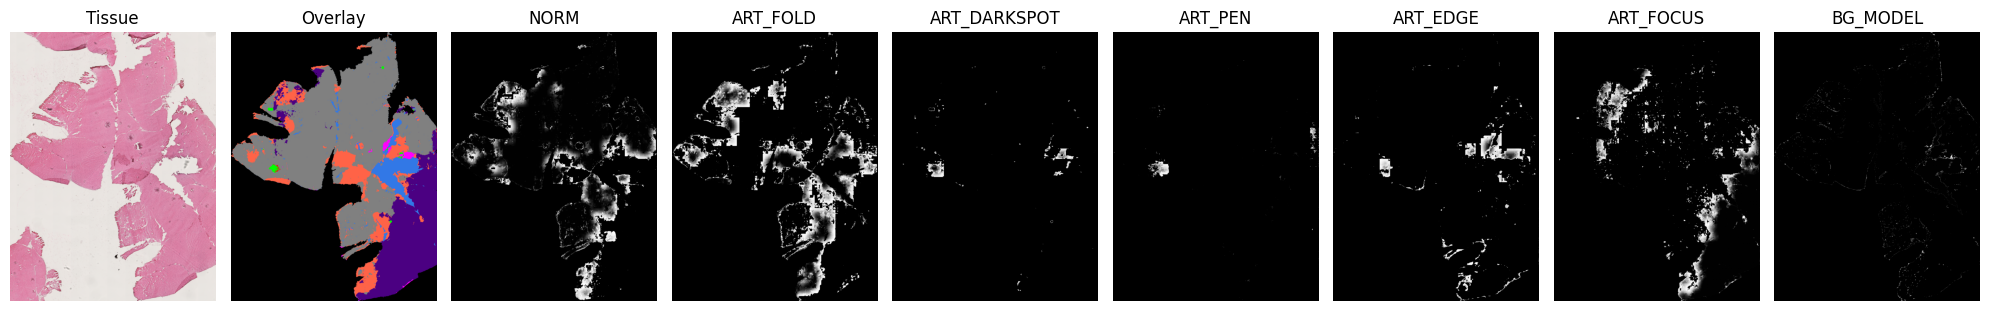

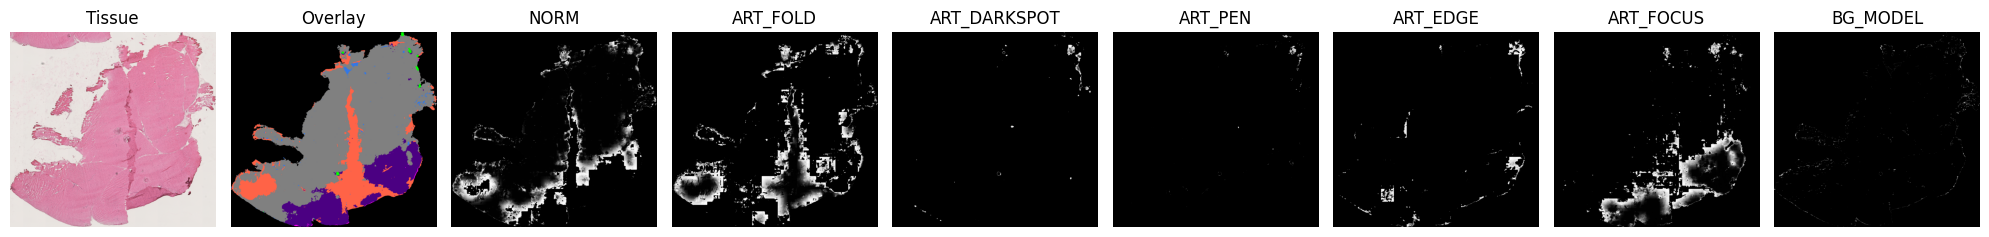

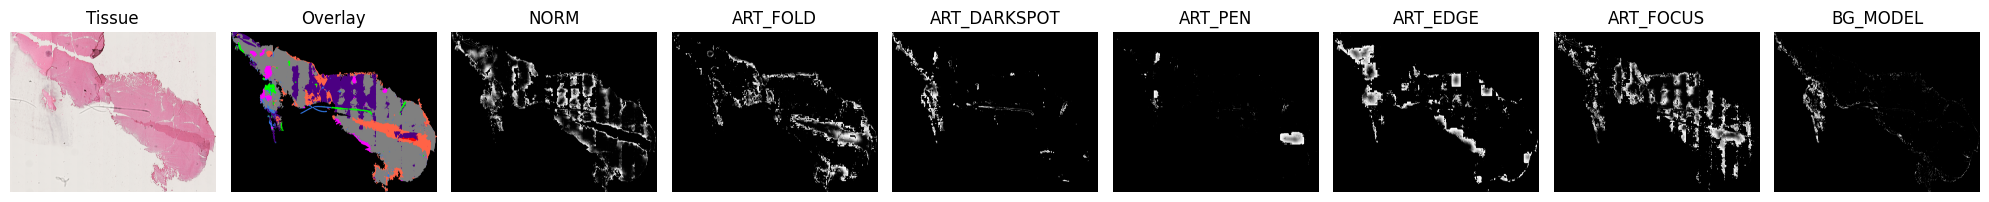

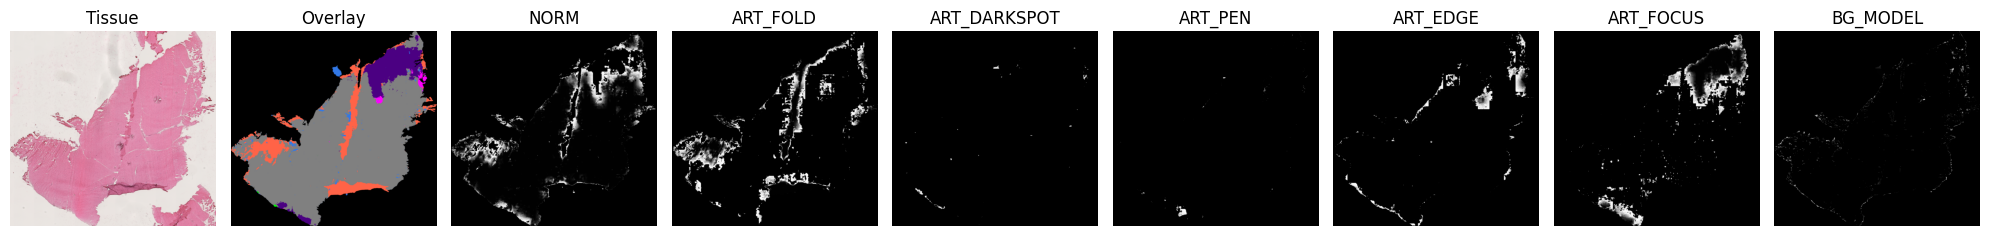

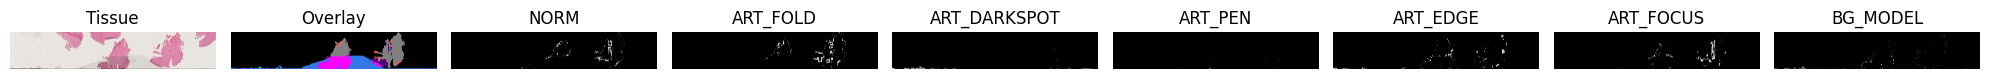

In [33]:
import os

import matplotlib.pyplot as plt
import numpy as np
from src.histo_kit.grand_qc.visualisation import make_artifacts_color_map
from src.histo_kit.utils.wsi import load_wsi_mag
from openslide import OpenSlide
import scipy.io as sio
from src.histo_kit.grand_qc.artifacts import Artifact

wsi_name = "51-21_he"
file = f"/mnt/data/Tmp/jmerta/test_data_bbox_res/grandqc_confidence_maps/{wsi_name}.mat"
slide = OpenSlide("/mnt/data/Tmp/jmerta/test_data_bbox/51-21_he.svs")
mat = sio.loadmat(f"/mnt/data/Tmp/jmerta/test_data_bbox_res/masks_grandqc/{wsi_name}.mat")

data = sio.loadmat(file)
region, scale_val, info, mpp_slide, ratio = load_wsi_mag(slide, 2.5, allow_upscaling=True)

for region_idx in range(mat['bbox'].shape[0]):
    raw_mask_art = data['mask_conf'][0][region_idx]
    bbox=mat['bbox'][region_idx]
    overlay = mat["mask_art"][0][region_idx]
    overlay = make_artifacts_color_map(overlay)
    region_0 = np.array(region)[bbox[0]:bbox[2], bbox[1]:bbox[3], :]

    plt.figure(figsize=(20, 4))

    min_val = 0
    max_val = 1

    raw_mask_art = (raw_mask_art-min_val)/(max_val-min_val)*255

    for ch in range(-1, 8):
        if ch==-1:
            img = region_0
            plt.subplot(1, 9, ch+2)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f'Tissue')
        elif ch==0:
            img = overlay
            plt.subplot(1, 9, ch+2)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f'Overlay')
        else:
            img = (raw_mask_art[:, :, ch]).astype(np.uint8)
            plt.subplot(1, 9, ch+2)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
            plt.title(f'{Artifact(ch).name}')

    plt.tight_layout()
    plt.show()


In [5]:
import glob
import os
import scipy.io as sio
regions_paths = glob.glob(os.path.join("/mnt/data/Tmp/jmerta/wsi_processed_test/masks_grandqc/", '*.mat'))

In [9]:
overlap_list = []
for r_p in regions_paths:
    mat = sio.loadmat(r_p)
    bboxes = mat['bbox']

    for i in range(len(bboxes)):
        for j in range(len(bboxes)):
            if i!=j:

                ymin_i = bboxes[i][0]
                ymax_i = bboxes[i][2]
                xmin_i = bboxes[i][1]
                xmax_i = bboxes[i][3]

                ymin_j = bboxes[j][0]
                ymax_j = bboxes[j][2]
                xmin_j = bboxes[j][1]
                xmax_j = bboxes[j][3]

                inter_w = min(xmax_i, xmax_j) - max(xmin_i, xmin_j)
                inter_h = min(ymax_i, ymax_j) - max(ymin_i, ymin_j)

                if max(inter_w,0)*max(inter_h,0) > 0 and r_p not in overlap_list:
                    overlap_list.append(r_p)


/tmp/ipykernel_2855453/791938945.py:20: RuntimeWarning: overflow encountered in scalar subtract
  inter_w = min(xmax_i, xmax_j) - max(xmin_i, xmin_j)
/tmp/ipykernel_2855453/791938945.py:23: RuntimeWarning: overflow encountered in scalar multiply
  if max(inter_w,0)*max(inter_h,0) > 0 and r_p not in overlap_list:
/tmp/ipykernel_2855453/791938945.py:21: RuntimeWarning: overflow encountered in scalar subtract
  inter_h = min(ymax_i, ymax_j) - max(ymin_i, ymin_j)


In [10]:
print(len(overlap_list))

93
